In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")

100%|██████████| 1.21M/1.21M [00:00<00:00, 1.91MB/s]

Extracting files...


# Loading the data

In [44]:
results = pd.read_csv(os.path.join(path, 'results.csv'))
goalscorers = pd.read_csv(os.path.join(path, 'goalscorers.csv'))
shootouts = pd.read_csv(os.path.join(path, 'shootouts.csv'))


# Convert dates to datetime objects for easier manibulation
results['date'] = pd.to_datetime(results['date'])
goalscorers['date'] = pd.to_datetime(goalscorers['date'])
shootouts['date'] = pd.to_datetime(shootouts['date'])

# Create a decades column
results['decade'] = (results['date'].dt.year // 10) * 10
shootouts['decade'] = (shootouts['date'].dt.year // 10) * 10

In [30]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


# Top Performers

## Top scorers by player

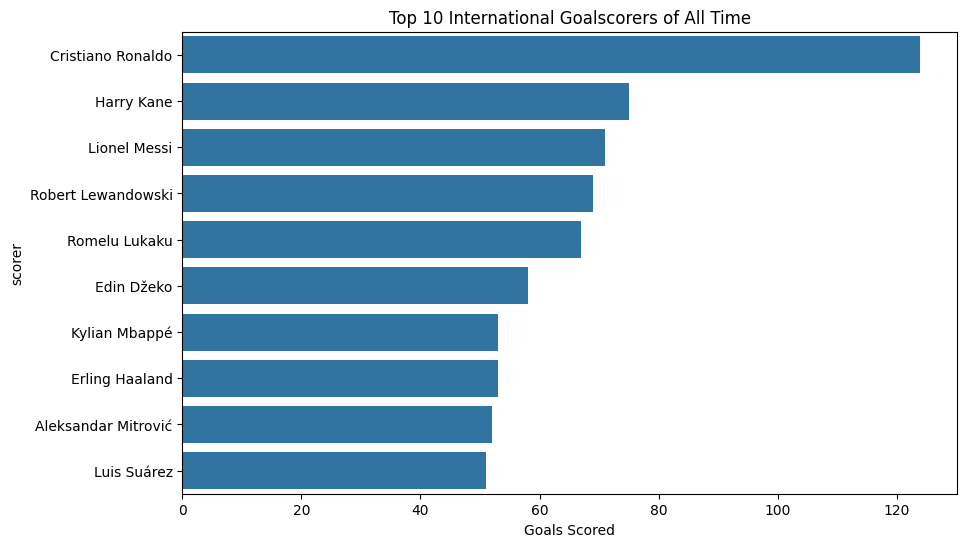

In [19]:
top_scorers = goalscorers['scorer'].value_counts().head(10) # value_counts() returns a sorted list of the values in the column

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index)
plt.title('Top 10 International Goalscorers of All Time')
plt.xlabel('Goals Scored')
plt.show()

## Top 10 scoring teams

In [20]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


[]

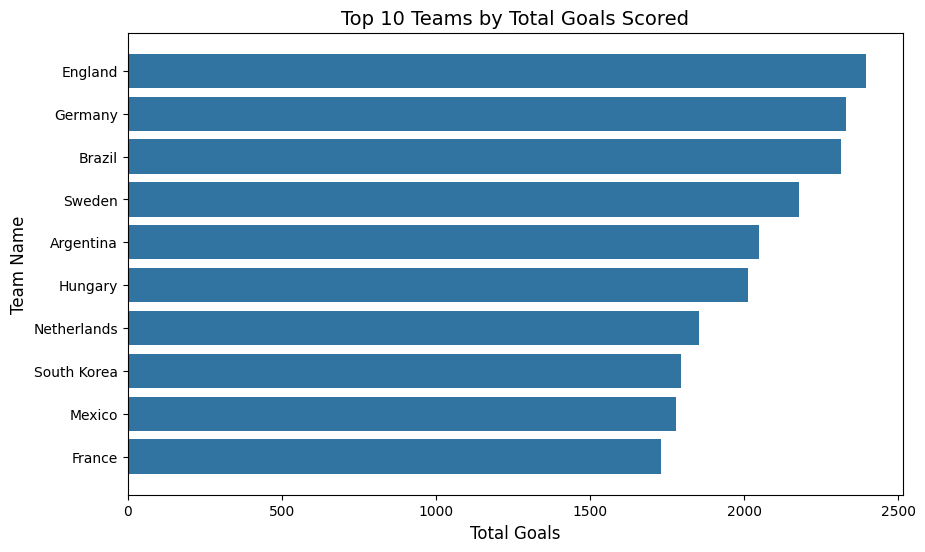

In [29]:

# Top 10 National Teams by Total Goals
# Calculate home goals and away goals separately, then aggregate
home_goals = results.groupby('home_team')['home_score'].sum()
away_goals = results.groupby('away_team')['away_score'].sum()

total_team_goals = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False)

top_ten_teams = total_team_goals.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_ten_teams.values, y=top_ten_teams.index)

plt.title('Top 10 Teams by Total Goals Scored', fontsize=14)
plt.xlabel('Total Goals', fontsize=12)
plt.ylabel('Team Name', fontsize=12)

plt.plot()

# Team effeciency

In [33]:
teams = pd.unique(results[['home_team', 'away_team']].values.ravel('K'))
team_stats = pd.DataFrame(0, index=teams, columns=['matches', 'points', 'goals_scored'], dtype=int)
team_stats.head()

,matches,points,goals_scored
Scotland,0,0,0
England,0,0,0
Wales,0,0,0
Northern Ireland,0,0,0
United States,0,0,0


In [ ]:
# Calculate stats
for index, row in results.iterrows():
    home = row['home_team']
    away = row['away_team']

    team_stats.at[home, 'matches'] += 1
    team_stats.at[away, 'matches'] += 1

    team_stats.at[home, 'goals_scored'] += row['home_score']
    team_stats.at[away, 'goals_scored'] += row['away_score']

    if row['home_score'] > row['away_score']:
        team_stats.at[home, 'points'] += 3
    elif row['home_score'] < row['away_score']:
        team_stats.at[away, 'points'] += 3
    else:
        team_stats.at[home, 'points'] += 1
        team_stats.at[away, 'points'] += 1



In [40]:
team_stats['points_per_match'] = team_stats['points'] / team_stats['matches']
team_stats['goals_per_match'] = team_stats['goals_scored'] / team_stats['matches']


threshold = 100
efficient_teams = team_stats[team_stats['matches'] >= threshold].sort_values(by='points_per_match', ascending=False)

print(f"\nTop 10 Most Efficient Teams (Min {threshold} matches):\n", efficient_teams[['matches', 'points_per_match', 'goals_per_match']].head(10))


Top 10 Most Efficient Teams (Min 100 matches):
              matches  points_per_match  goals_per_match
Brazil          1064          2.107143         2.175752
Jersey           235          2.038298         2.744681
Spain            791          2.003793              NaN
England         1098          1.958106              NaN
Germany         1035          1.948792         2.252174
Iran             615          1.941463         1.882927
Guernsey         240          1.916667         2.566667
Argentina       1077          1.908078              NaN
Italy            893          1.874580         1.752520
South Korea     1010          1.850495         1.776238


# Drama Analysis

In [41]:
# Add decade to shootouts
shootouts['decade'] = (shootouts['date'].dt.year // 10) * 10

# Shootouts per decade
shootouts_per_decade = shootouts['decade'].value_counts().sort_index()
print("\nPenalty Shootouts per Decade:\n", shootouts_per_decade)

# Merge shootouts with results to get tournament data
shootouts_with_tournaments = pd.merge(shootouts, results[['date', 'home_team', 'away_team', 'tournament']], 
                                      on=['date', 'home_team', 'away_team'], how='left')

# Tournaments causing the most shootouts
top_shootout_tournaments = shootouts_with_tournaments['tournament'].value_counts().head(5)
print("\nTournaments with the Most Shootouts:\n", top_shootout_tournaments)


Penalty Shootouts per Decade:
 decade
1960      1
1970     38
1980     97
1990    126
2000    144
2010    153
2020    124
Name: count, dtype: int64

Tournaments with the Most Shootouts:
 tournament
Friendly                  79
COSAFA Cup                63
African Cup of Nations    47
FIFA World Cup            39
Copa América              33
Name: count, dtype: int64


# Worst performers

In [42]:
# Sort goalscorers by date, match, and minute to find the first goal of each match
first_goals = goalscorers.sort_values(['date', 'home_team', 'away_team', 'minute']).drop_duplicates(subset=['date', 'home_team', 'away_team'], keep='first')

# Merge with results to see match outcomes
first_goal_outcomes = pd.merge(first_goals, results, on=['date', 'home_team', 'away_team'], how='inner')

# Determine if the team that scored first failed to win (drew or lost)
def failed_to_win(row):
    scorer_team = row['team']
    home_team = row['home_team']
    
    # Did home team score first?
    if scorer_team == home_team:
        return row['home_score'] <= row['away_score'] # Failed to win if score is <=
    else:
        return row['away_score'] <= row['home_score'] # Away team scored first

first_goal_outcomes['failed_to_win'] = first_goal_outcomes.apply(failed_to_win, axis=1)

# Count how many times each team failed to win after scoring first
choke_stats = first_goal_outcomes[first_goal_outcomes['failed_to_win'] == True]['team'].value_counts().head(10)
print("\nTeams that most often score first and fail to win:\n", choke_stats)


Teams that most often score first and fail to win:
 team
Brazil                 57
Switzerland            54
Uruguay                52
Sweden                 51
Republic of Ireland    50
Spain                  49
Denmark                49
Paraguay               48
Belgium                48
Poland                 47
Name: count, dtype: int64


# Era Comparison & Outlier Detection


Era Comparison (Decade by Decade):
     decade  goals_per_match  draw_rate  avg_winning_margin
0     1870         4.538462   0.153846            3.000000
1     1880         5.581818   0.090909            4.220000
2     1890         5.152542   0.152542            3.640000
3     1900         4.159420   0.173913            2.771930
4     1910         4.218182   0.160606            2.779783
5     1920         3.884477   0.179302            2.521994
6     1930         4.318814   0.159407            2.485116
7     1940         4.344538   0.153661            2.852482
8     1950         4.004240   0.183525            2.469585
9     1960         3.478963   0.196230            2.381072
10    1970         2.974837   0.218243            2.215723
11    1980         2.526766   0.261294            2.013200
12    1990         2.778946   0.242944            2.196500
13    2000         2.801973   0.234442            2.205072
14    2010         2.738429   0.232656            2.161518
15    2020         

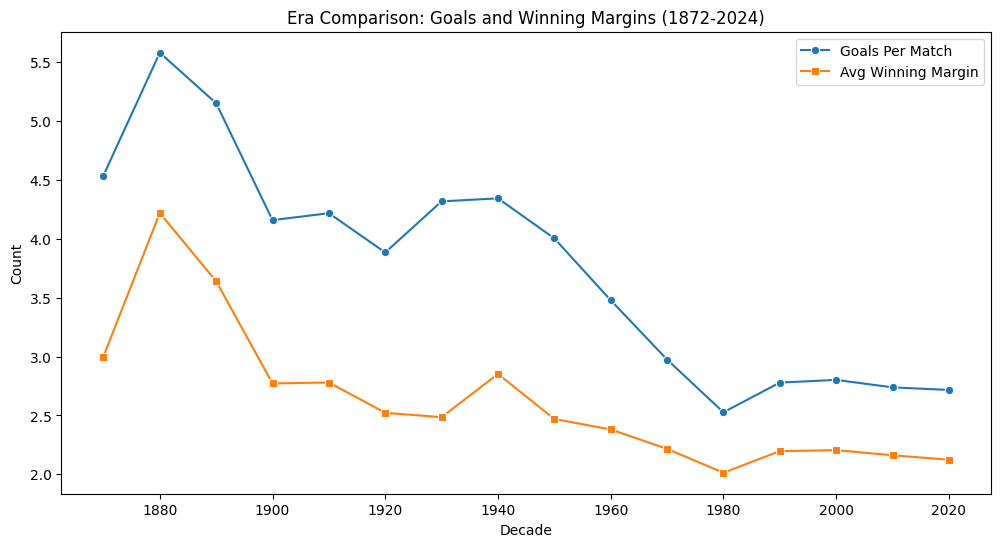

In [45]:
# Feature Engineering: Goal margin and Match outcome
results['total_goals'] = results['home_score'] + results['away_score']
results['goal_margin'] = abs(results['home_score'] - results['away_score'])
results['is_draw'] = results['home_score'] == results['away_score']

# Era Comparison: Aggregate by Decade
era_stats = results.groupby('decade').agg(
    goals_per_match=('total_goals', 'mean'),
    draw_rate=('is_draw', 'mean'),
    avg_winning_margin=('goal_margin', lambda x: x[x > 0].mean()) # Margin for matches that didn't end in a draw
).reset_index()

print("\nEra Comparison (Decade by Decade):\n", era_stats)

# Outlier Detection: Most lopsided match
max_margin = results['goal_margin'].max()
lopsided_match = results[results['goal_margin'] == max_margin]
print("\nMost Lopsided Match Ever Played:\n", lopsided_match[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']])

# Visualization: Era Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=era_stats, x='decade', y='goals_per_match', marker='o', label='Goals Per Match')
sns.lineplot(data=era_stats, x='decade', y='avg_winning_margin', marker='s', label='Avg Winning Margin')
plt.title('Era Comparison: Goals and Winning Margins (1872-2024)')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.legend()
plt.show()